In [70]:
#載入套件
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [71]:
#使用資料夾內鐵達尼號的資料集，練習邏輯迴歸的處理邏輯
train = pd.read_csv('data/titanic_data.csv')
train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C


<Axes: >

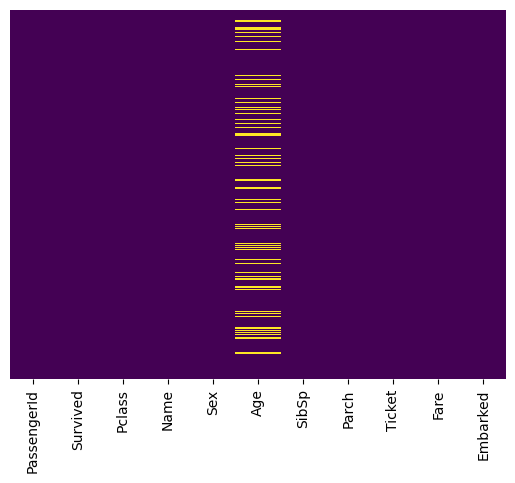

In [72]:
#探索資料
#用heatmap(.isnull()來找出缺失的資料在哪些欄位。Age似乎約有五分之一的資料缺失，可用合理資料補充。)
sns.heatmap(train.isnull(),yticklabels=False,cbar=False,cmap='viridis')

<Axes: xlabel='Survived', ylabel='count'>

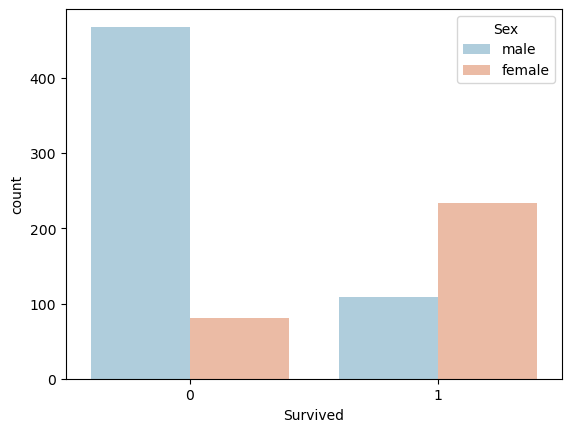

In [73]:
#用countplot來看性別是否影響最後存活。女性存活比例比男性高。
sns.countplot(x='Survived',hue='Sex',data=train,palette='RdBu_r')

<Axes: xlabel='Survived', ylabel='count'>

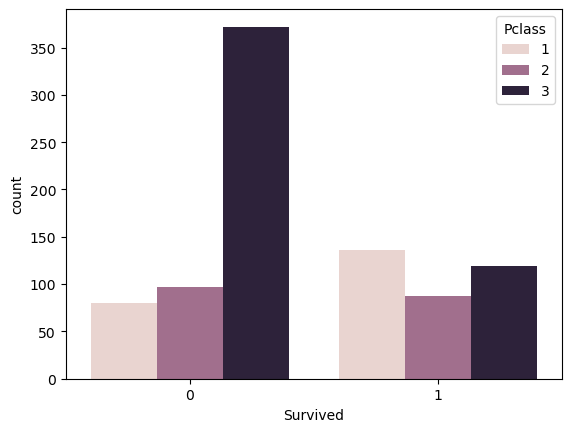

In [74]:
#艙等是否也影響存活?
sns.countplot(x='Survived',hue='Pclass',data=train)


<Axes: xlabel='Age', ylabel='Count'>

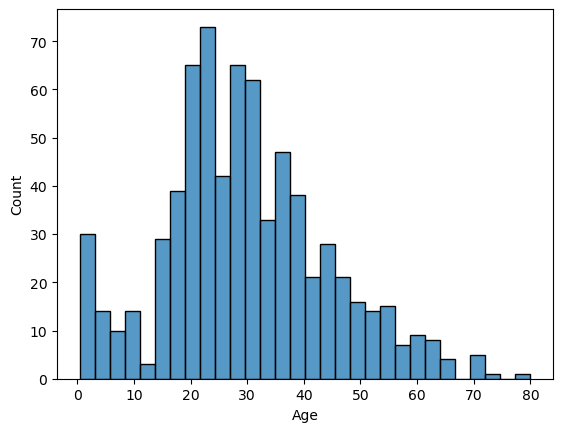

In [75]:
#用直方圖看年齡分佈。缺失資料在此不計。
#sns.distplot(train['Age'].dropna(),kde=False,bins=30)

sns.histplot(train['Age'].dropna(), bins=30, kde=False)
#plt.show()

<Axes: xlabel='SibSp', ylabel='count'>

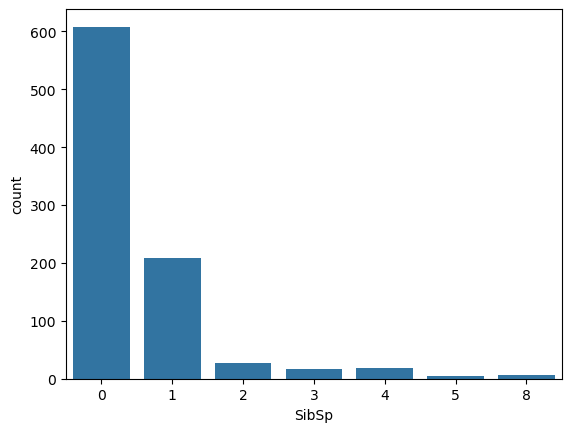

In [76]:
#SibSp代表兄弟姐妹或眷屬人數
sns.countplot(x='SibSp',data=train)

<Axes: >

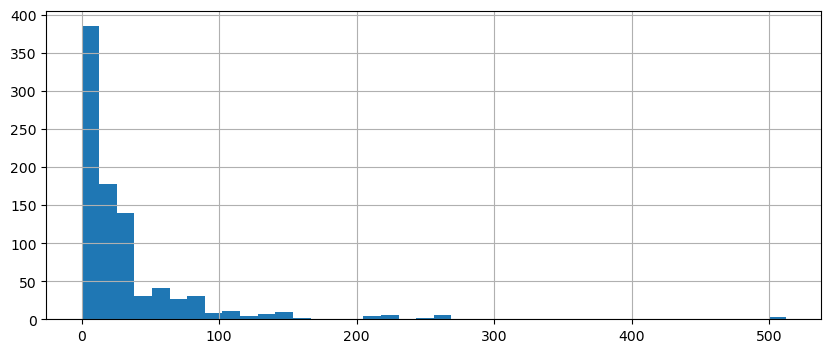

In [77]:
#用直方圖看票價分佈
train['Fare'].hist(bins=40,figsize=(10,4))

<Axes: xlabel='Pclass', ylabel='Age'>

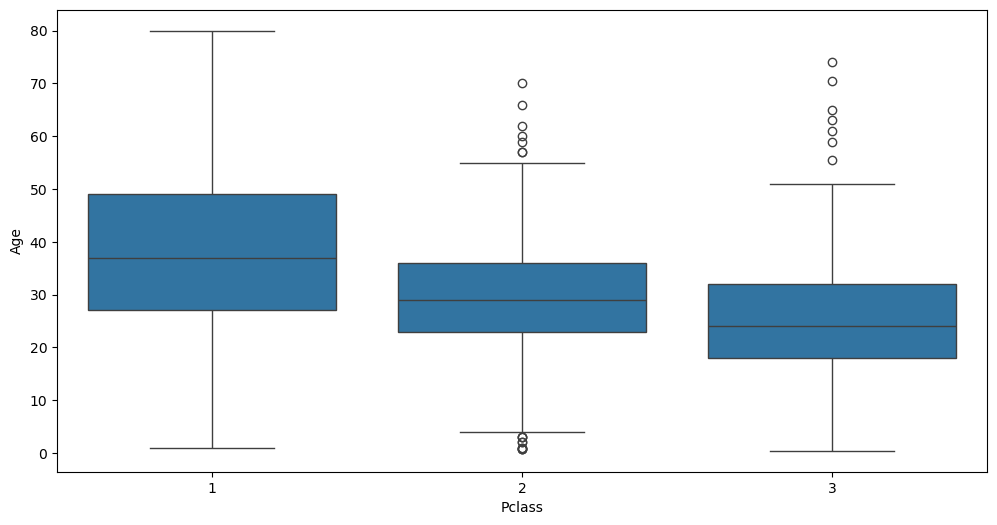

In [78]:
#資料清理
#剛有看到年齡資料約有五分之一缺失，一種做法是棄之不用，一種可以考慮把年齡平均放進去。
#使用盒鬚圖來看年齡和艙等的分佈。看起來頭等艙年齡較高，隨之降低。
plt.figure(figsize=(12,6))
sns.boxplot(x='Pclass',y='Age',data=train)

In [79]:
print(train)

#把艙等平均年齡填入缺失的資料中
#艙等1平均年齡是37，艙等2平均年齡是29，艙等3平均年齡是24
def impute_age(cols):
    #Age = cols[0]
    #Pclass = cols[1]
    Age = cols.iloc[0]
    Pclass = cols.iloc[1]

    if pd.isnull(Age):
        if Pclass == 1:
            return 37
        elif Pclass == 2:
            return 29
        else:
            return 24
    else:
        return Age

train['Age'] = train[['Age','Pclass']].apply(impute_age,axis=1)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

<Axes: >

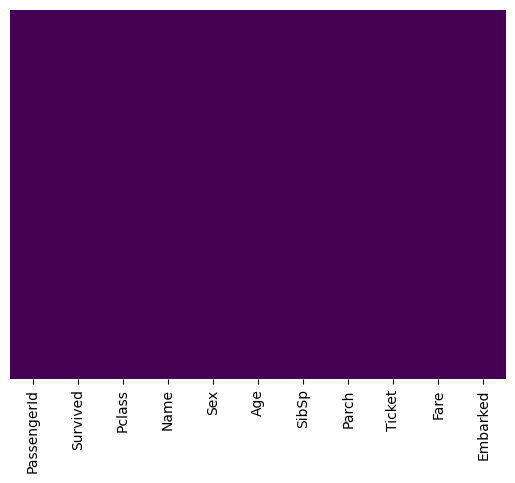

In [80]:
#用heatmap查看年齡是否還有缺失資料
sns.heatmap(train.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [81]:
#rain.head(10)
#train.shape
train.dropna(inplace=True)#inplace： False: 返回新的數據集（默認） True: 在原數據集上操作
train.shape
#train2=train

(889, 11)

In [82]:
#print("train2\n")
#print(train2.columns)
#虛擬變數範例
#使用pandas(d.get_dummies)將性別從類別資料轉為數值變數。
sex = pd.get_dummies(train['Sex'],drop_first=True).astype(int)
#sex = pd.get_dummies(train['Sex'],drop_first=False).astype(int)

#Note
#(1)sex = pd.get_dummies(train['Sex'],drop_first=False).astype(int)
#將Sex 欄位的 male & female 轉成多兩個名為male & female的欄位,其值為 or 1, 且保留Sex欄位
#(2)sex = pd.get_dummies(train['Sex'],drop_first=True).astype(int)
#將Sex 欄位的 male & female 轉成多兩個名為male & female的欄位,其值為 or 1, 且保留Sex欄位, 並將female欄位刪除 
#(drop_first=True 會刪掉「排序後的第一個類別」所產生的 dummy 欄位。)


#請將drop_first=True，如果為True會刪除第一個類別值。
#本來若有k個level，drop_first=True會只剩下k-1個level，降低共線性的可能
sex.head(10)
#print("train=",train)


#train3=train2
#print("train3\n")
#print(train3.columns)
#train3=train2
#print("train3\n",train2)

,male
0,1
1,0
2,0
3,0
4,1
5,1
6,1
7,1
8,0
9,0


In [83]:
#使用pandas將上船的港口從類別資料改換為數值變數(drop_first=True)
embark = pd.get_dummies(train['Embarked'],drop_first=True).astype(int)
embark.head()
#train

,Q,S
0,0,1
1,0,0
2,0,1
3,0,1
4,0,1


In [84]:
#將性別及上船港口的數值變數和原始的data結合
#train
#train = pd.concat([train,sex,embark],axis=1)
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [85]:
#將原始的性別、登船港口、票號、姓名欄位棄用
train.drop(['Sex','Embarked','Name','Ticket'],axis=1,inplace=True)
train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


In [86]:
#因為PassengerId在此也只是排序，因此也棄用
train.drop('PassengerId',axis=1,inplace=True)
train.head()

,Survived,Pclass,Age,SibSp,Parch,Fare
0,0,3,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,1,3,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,0,3,35.0,0,0,8.0500


In [100]:
#建立feature資料集(選取survived以外所有欄位)與target資料集(survived)
X = train.drop('Survived',axis=1)
y = train['Survived']
print("X=\n",X.head())
print("y=\n",y.head())

X=
    Pclass   Age  SibSp  Parch     Fare
0       3  22.0      1      0   7.2500
1       1  38.0      1      0  71.2833
2       3  26.0      0      0   7.9250
3       1  35.0      1      0  53.1000
4       3  35.0      0      0   8.0500
y=
 0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


In [88]:
#載入訓練組及測試組分組套件
from sklearn.model_selection import train_test_split

In [ ]:
#設定隨機種子(random_state)為101，測試組比例佔30%
#101 本身沒有特別意義，只是一個固定的數字。
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=101)

In [90]:
#載入邏輯回歸
from sklearn.linear_model import LogisticRegression

In [91]:
#建立訓練組邏輯迴歸模型
logmodel = LogisticRegression()
logmodel.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
#X_train：考前練習題目
#y_train：練習題答案
#X_test：正式考試題目
#y_test：正式考試答案


#使用模型進行測試集資料的預測
#這時候模型只看到 X_test，產生預測結果 predictions。
#然後我們再用：predictions == y_test.values
#檢查模型預測得對不對。
predictions = logmodel.predict(X_test)
predictions2 = logmodel.predict(X_train)

In [ ]:
#ground truth
#y_test 是 Pandas Series：
#y_test.values 是把 y_test 轉成 NumPy array：
print(y_test.values)
print(y_train.values)

[0 0 1 1 0 0 0 0 0 1 1 1 0 1 0 0 1 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1
 0 0 0 0 0 0 1 0 0 1 1 0 0 1 1 0 0 0 0 0 1 0 1 1 1 1 0 1 0 0 1 0 0 1 1 1 1
 0 0 0 0 0 0 1 0 1 0 0 1 0 1 0 1 0 1 0 0 1 1 1 1 0 1 1 1 0 1 0 1 1 0 0 1 0
 0 1 1 0 1 0 0 1 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 0 0 1 0 0 0 0 0 0 1 0 0
 0 1 0 1 0 1 0 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1 1 1 0 0 0 1 0 1 0 1 0 1 1 0
 1 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 1 0 0 1 1 0 0 1 1 0
 0 1 1 0 0 0 0 0 1 0 0 0 0 1 1 0 1 0 0 0 1 1 1 0 0 1 0 1 0 1 0 0 0 0 0 1 0
 1 1 0 0 1 0 1 0]
[0 1 1 1 0 0 1 1 0 1 0 0 1 1 1 0 1 0 1 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0
 1 1 0 0 0 0 1 1 1 0 0 1 0 0 0 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 0 0 1
 0 0 1 0 0 1 1 0 1 0 1 0 1 1 1 1 0 1 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 1 1
 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 1 1 0 1 0 1 1 0 0
 1 0 0 1 1 0 1 1 1 0 0 1 0 1 1 1 0 0 0 1 0 1 0 0 0 1 1 1 1 0 0 0 0 0 1 0 0
 1 0 1 0 1 0 1 0 1 0 0 0 0 1 1 0 1 0 0 0 0 1 0 1 1 0 0 1 0 0 1 0 0 1 0 1 0
 0 0 1 

#### 計算accuracy及結果顯示
accuracy<br>
error_index #錯誤答案是哪幾筆資料<br>
miss classification #錯誤答案<br>
錯誤欄位的正確之原始資料表格

In [ ]:
#predictions = logmodel.predict(X_test)
#predictions2 = logmodel.predict(X_train)
#predictions2 是模型對訓練資料的預測答案：
#模predictions2 是在比較：!= y_train.values 型預測答案 是否不等於 真正答案 它會得到一串 True / False。
#(array([2]),) 最後加上 [0]：是把結果中的第一個陣列取出來：error_index2 會存放「預測錯誤的索引位置」。

error_index2=np.where(predictions2!=y_train.values)[0]
#print("error_index2=",error_index2)
print('train accuracy:',1-len(error_index2)/len(X_train))


error_index=np.where(predictions!=y_test.values)[0]
print('test accuracy:',1-len(error_index)/len(X_test))

error_index2= [  2   7  10  13  14  16  18  33  37  43  44  45  55  63  68  76  79  82
  83  84  87  90  91  93  94  95 102 104 109 110 113 117 119 129 135 136
 138 139 142 152 161 163 167 169 173 174 175 180 189 191 193 201 209 212
 213 215 219 224 228 236 238 240 242 249 261 262 263 265 268 271 273 277
 282 284 285 288 291 293 294 296 299 300 301 303 309 314 319 320 325 328
 330 333 335 341 344 349 351 352 354 361 368 369 371 372 375 379 382 385
 387 391 394 403 405 409 411 412 415 426 427 428 431 432 433 436 438 439
 442 447 448 449 451 455 461 462 465 472 474 476 478 480 484 486 490 492
 494 498 499 500 502 503 505 508 509 510 513 514 515 519 531 533 538 543
 547 548 553 556 558 559 562 563 564 565 569 570 571 579 583 585 594 595
 598 612 613 614 616 617 619 621]
train accuracy: 0.6977491961414791
test accuracy: 0.7265917602996255


In [95]:
print('error_index:',error_index)
print('miss classification :',predictions[error_index])#錯誤答案
data_index=train.iloc[error_index].index#這裡變數train是所有資料
train.iloc[data_index]#錯誤欄位的正確之原始資料

error_index: [  9  10  13  17  18  22  23  26  29  35  36  46  51  56  57  60  71  72
  80  81  84  85  87  91  96 100 103 105 111 118 119 120 122 126 134 144
 145 147 151 153 168 170 171 173 180 183 185 189 191 192 199 200 206 210
 212 213 216 219 223 224 230 234 236 238 243 244 247 249 251 252 257 260
 263]
miss classification : [0 0 0 0 0 1 1 1 1 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0
 1 0 0 1 0 0 1 0 0 0 0 1 0 1 1 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0]


,Survived,Pclass,Age,SibSp,Parch,Fare
9,1,2,14.0,1,0,30.0708
10,1,3,4.0,1,1,16.7000
13,0,3,39.0,1,5,31.2750
17,1,2,29.0,0,0,13.0000
18,0,3,31.0,1,0,18.0000
...,...,...,...,...,...,...
253,0,3,30.0,1,0,16.1000
254,0,3,41.0,0,2,20.2125
259,1,2,50.0,0,1,26.0000
262,0,1,52.0,1,1,79.6500
